Кранк-Николсон, влияние Smax

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Optional, Tuple
import pandas as pd
from matplotlib import animation
from IPython.display import HTML

# Параметры модели
sigma = 0.2
r = 0.05
T = 1.0
K = 100.0

def bs_call_price(S, K, r, sigma, tau):
    S = np.asarray(S, dtype=float)
    if tau <= 1e-15:
        return np.maximum(S - K, 0.0)
    S_eff = np.maximum(S, 1e-18)
    vol = sigma * math.sqrt(tau)
    d1 = (np.log(S_eff / K) + (r + 0.5 * sigma**2) * tau) / vol
    d2 = d1 - vol
    Phi = lambda x: 0.5*(1.0 + math.erf(x / math.sqrt(2.0)))
    vPhi = np.vectorize(Phi)
    return S * vPhi(d1) - K * math.exp(-r * tau) * vPhi(d2)

def fair_call_price(S: float, K: float, r: float, sigma: float, time_to_maturity: float) -> float:
    return float(bs_call_price(S, K, r, sigma, time_to_maturity))

In [2]:

@dataclass
class Grid:
    M: int
    N: int
    S: np.ndarray
    tau: np.ndarray
    dS: float
    dtau: float
    Smax: float

def build_grid_with_fixed_dS(Smax: float, T: float, dS: float, N: int) -> Grid:
    M = int(round(Smax / dS))
    Smax_adj = dS * M
    S = np.linspace(0.0, Smax_adj, M + 1)
    tau = np.linspace(0.0, T, N + 1)
    return Grid(M=M, N=N, S=S, tau=tau, dS=dS, dtau=T/N, Smax=Smax_adj)

def bs_coeffs(Si: np.ndarray, dS: float, r: float, sigma: float):
    a = 0.5 * sigma**2 * Si**2 / (dS**2) - 0.5 * r * Si / dS
    b = - (sigma**2 * Si**2) / (dS**2) - r
    c = 0.5 * sigma**2 * Si**2 / (dS**2) + 0.5 * r * Si / dS
    return a, b, c

def thomas_solver(l, d, u, b):
    n = len(d)
    for i in range(1, n):
        w = l[i] / d[i-1]
        d[i] = d[i] - w * u[i-1]
        b[i] = b[i] - w * b[i-1]
    x = np.zeros_like(b)
    x[-1] = b[-1] / d[-1]
    for i in range(n-2, -1, -1):
        x[i] = (b[i] - u[i] * x[i+1]) / d[i]
    return x

def solve_crank_nicolson(grid: Grid, K: float, r: float, sigma: float,
                         collect_every: Optional[int] = None):
    M, N, S, dS, dt, Smax = grid.M, grid.N, grid.S, grid.dS, grid.dtau, grid.Smax
    Vn = np.maximum(S - K, 0.0)
    i_idx = np.arange(1, M)
    Si = S[i_idx]
    a, b, c = bs_coeffs(Si, dS, r, sigma)
    l = -0.5 * dt * a
    d =  1.0 - 0.5 * dt * b
    u = -0.5 * dt * c

    snaps = []
    if collect_every is not None and collect_every > 0:
        snaps.append(Vn.copy())

    for n in range(N):
        tau_n   = grid.tau[n]
        tau_np1 = grid.tau[n+1]
        rhs = (1.0 + 0.5*dt*b) * Vn[1:M] + 0.5*dt*(a * Vn[0:M-1] + c * Vn[2:M+1])
        V0_n, V0_np1 = 0.0, 0.0
        VM_n   = Smax - K * math.exp(-r * tau_n)
        VM_np1 = Smax - K * math.exp(-r * tau_np1)
        rhs[0]  += 0.5*dt*a[0]*V0_n   + (-l[0])*V0_np1
        rhs[-1] += 0.5*dt*c[-1]*VM_n  + (-u[-1])*VM_np1
        x = thomas_solver(l.copy(), d.copy(), u.copy(), rhs.copy())
        Vnext = np.zeros_like(Vn)
        Vnext[0], Vnext[-1] = V0_np1, VM_np1
        Vnext[1:M] = x
        Vn = Vnext
        if collect_every is not None and collect_every > 0 and ((n+1) % collect_every == 0):
            snaps.append(Vn.copy())
    return Vn, snaps

,Smax,M (узлов),N,dS,dt,||err||_inf,RMSE,MAE
0,150.00,201,1000,0.75,0.001,26.824590,8.108677,3.949247
1,200.25,268,1000,0.75,0.001,51.839687,15.787764,7.726046
2,300.00,401,1000,0.75,0.001,101.520688,31.058062,15.250927


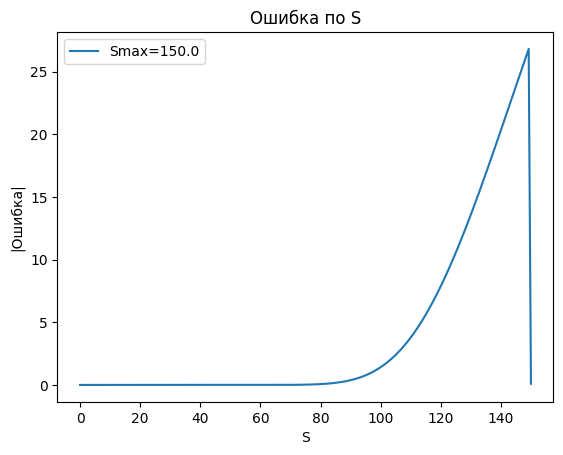

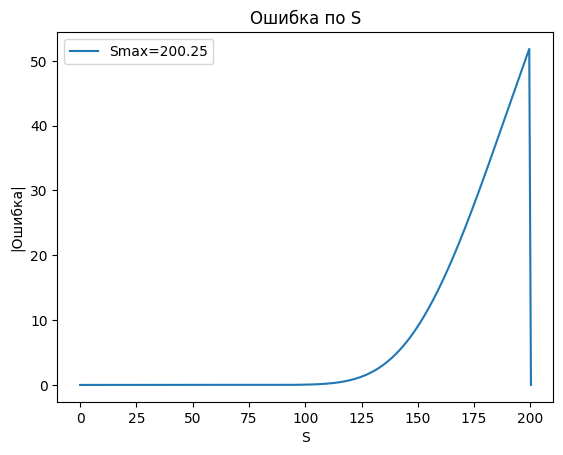

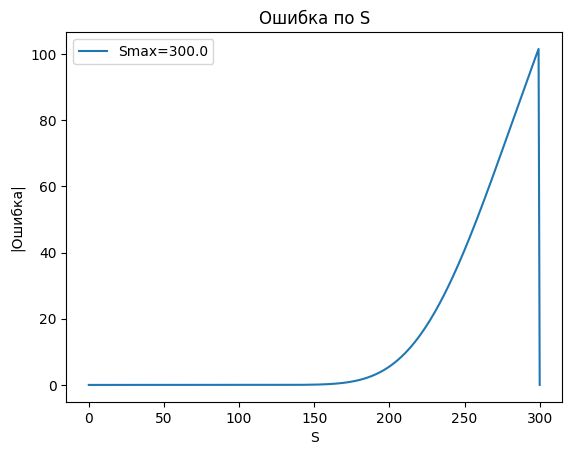

In [3]:

# Исследование влияния Smax на погрешность (по аналитике на tau=T)
Smax_list = [1.5*K, 2.0*K, 3.0*K]
dS_base = 0.75
N_time = 1000

rows = []
solutions = {}
for Smax in Smax_list:
    grid = build_grid_with_fixed_dS(Smax=Smax, T=T, dS=dS_base, N=N_time)
    V_cn, _ = solve_crank_nicolson(grid, K=K, r=r, sigma=sigma)
    S = grid.S
    V_exact = bs_call_price(S, K, r, sigma, T)
    err = np.abs(V_cn - V_exact)
    rows.append({
        "Smax": grid.Smax, "M (узлов)": grid.M + 1, "N": grid.N,
        "dS": grid.dS, "dt": grid.dtau,
        "||err||_inf": err.max(),
        "RMSE": float(np.sqrt(np.mean(err**2))),
        "MAE": float(np.mean(err))
    })
    solutions[grid.Smax] = (S, V_cn, V_exact, err)

df_smax = pd.DataFrame(rows)
display(df_smax.round(8))

# Визуализация распределения ошибки по S
for Smax in Smax_list:
    Smax_adj = dS_base * int(round(Smax/dS_base))
    S, V_cn, V_exact, err = solutions[Smax_adj]
    plt.figure()
    plt.plot(S, err, label=f"Smax={Smax_adj}")
    plt.xlabel("S"); plt.ylabel("|Ошибка|"); plt.title("Ошибка по S")
    plt.legend(); plt.show()


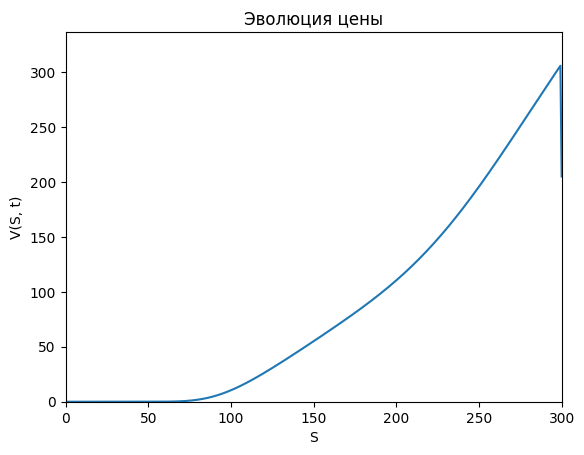

In [4]:

# Анимация: эволюция V(S, t)
Smax_anim = 3.0 * K
dS_anim = 0.75
N_anim = 600
collect_every = 6

grid_anim = build_grid_with_fixed_dS(Smax=Smax_anim, T=T, dS=dS_anim, N=N_anim)
V_final, snaps = solve_crank_nicolson(grid_anim, K=K, r=r, sigma=sigma, collect_every=collect_every)
S = grid_anim.S

fig, ax = plt.subplots()
line, = ax.plot([], [])
ax.set_xlim(S[0], S[-1])
ax.set_ylim(0, max(S[-1]-K, 1.1*np.max(snaps[-1])))
ax.set_xlabel("S"); ax.set_ylabel("V(S, t)")

def init():
    line.set_data([], [])
    return line,

def update(frame_idx):
    line.set_data(S, snaps[frame_idx])
    ax.set_title(f"Эволюция цены")
    return line,

ani = animation.FuncAnimation(fig, update, frames=len(snaps), init_func=init, blit=True, interval=60)
HTML(ani.to_jshtml())


Справедливая цена

In [5]:
print("Пример:", fair_call_price(100.0, 100.0, 0.05, 0.2, 1.0))

Пример: 10.450583572185565
